# Lithium Reuters Data Analysis
Analysis of all lithium price series from Reuters Excel exports in `data/reuters_data/lithium_4_26`.

## 1. Import Required Libraries

In [1]:
import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded.")

Libraries loaded.


## 2. Load and Extract Data from Excel Files

Each Excel file has a Reuters-style layout with metadata rows at the top. The extraction logic:
- Reads the **ticker** from row 3 (0-indexed)  
- Reads the **series title** from row 0  
- Finds the actual data table by searching for the `"Exchange Date"` or `"History"` header row  
- For **2-column files** the price column is `Trade Price`; for **multi-column files** the price column is `Close`

In [2]:
FOLDER = os.path.join(os.path.dirname(os.getcwd()), "data", "reuters_data", "lithium_4_26")
xlsx_files = sorted(glob.glob(os.path.join(FOLDER, "*.xlsx")))
print(f"Found {len(xlsx_files)} Excel files:")
for f in xlsx_files:
    print(" ", os.path.basename(f))

Found 10 Excel files:
  Price History_20260421_2127.xlsx
  Price History_20260421_2129 (1).xlsx
  Price History_20260421_2129.xlsx
  Price History_20260421_2130.xlsx
  Price History_20260421_2132.xlsx
  Price History_20260421_2133.xlsx
  Price History_20260421_2136.xlsx
  Price History_20260421_2137.xlsx
  Price History_20260421_2139.xlsx
  Price History_20260421_2140.xlsx


In [3]:
def extract_series(filepath):
    """
    Extract (ticker, title, DataFrame with columns [date, price]) from a Reuters-style Excel file.
    Handles both 2-column (Trade Price) and multi-column (Close) layouts.
    """
    raw = pd.read_excel(filepath, sheet_name=0, header=None)

    # --- Metadata ---
    title_raw = str(raw.iloc[0, 0])
    # Strip the timestamp suffix after '|'
    title = re.sub(r"\s*\|\s*Price History.*$", "", title_raw).strip()

    # Ticker is in the first non-null cell after row 1 that doesn't start with 'Interval' or 'History'
    ticker = None
    for i in range(1, 8):
        val = raw.iloc[i, 0]
        if pd.notna(val) and not str(val).startswith(("Interval", "History")):
            ticker = str(val).strip()
            break
    if ticker is None:
        ticker = os.path.splitext(os.path.basename(filepath))[0]

    # --- Find the header row for the price history table ---
    # Look for a row where col 0 == "Exchange Date" OR col 0 starts with ticker and contains "History"
    header_row = None
    for i, row in raw.iterrows():
        val0 = str(row.iloc[0]) if pd.notna(row.iloc[0]) else ""
        val1 = str(row.iloc[1]) if pd.notna(row.iloc[1]) else ""
        if val0 == "Exchange Date":
            header_row = i
            break
        # multi-col layout: next row after "TICKER History ..." line is the column header
        if ticker and ticker in val0 and "History" in val0:
            header_row = i + 1
            break

    if header_row is None:
        print(f"  [WARN] Could not find header row in {os.path.basename(filepath)}")
        return ticker, title, None

    # --- Extract data rows ---
    col_names = raw.iloc[header_row].tolist()
    data = raw.iloc[header_row + 1 :].copy()
    data.columns = col_names

    # Keep only date + price columns
    date_col = col_names[0]          # always "Exchange Date"
    if "Trade Price" in col_names:
        price_col = "Trade Price"
    elif "Close" in col_names:
        price_col = "Close"
    else:
        # fall back to second column
        price_col = col_names[1]

    df = data[[date_col, price_col]].copy()
    df.columns = ["date", "price"]
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df = df.dropna(subset=["date", "price"])
    df = df.sort_values("date").reset_index(drop=True)

    return ticker, title, df


# --- Run extraction ---
series_dict = {}   # ticker -> {"title": ..., "df": ...}

for fp in xlsx_files:
    fname = os.path.basename(fp)
    print(f"\nProcessing: {fname}")
    ticker, title, df = extract_series(fp)
    print(f"  Ticker : {ticker}")
    print(f"  Title  : {title}")
    if df is not None:
        print(f"  Rows   : {len(df)}  |  Range: {df['date'].min().date()} → {df['date'].max().date()}")
        # If ticker already exists (same ticker, different date range) keep the longer one
        if ticker in series_dict:
            existing = series_dict[ticker]["df"]
            combined = pd.concat([existing, df]).drop_duplicates("date").sort_values("date").reset_index(drop=True)
            series_dict[ticker]["df"] = combined
            series_dict[ticker]["title"] = title   # use the more descriptive one
            print(f"  → Merged with existing {ticker} series. New length: {len(combined)}")
        else:
            series_dict[ticker] = {"title": title, "df": df}
    else:
        print("  → Skipped (no data extracted)")

print(f"\n✓ Extracted {len(series_dict)} unique series.")


Processing: Price History_20260421_2127.xlsx
  Ticker : SMM-LIB-GRD
  Title  : SMM Battery Grade Lithium Metal
  Rows   : 21  |  Range: 2026-03-23 → 2026-04-21

Processing: Price History_20260421_2129 (1).xlsx
  Ticker : SMM-LIB-GRD
  Title  : SMM Battery Grade Lithium Metal
  Rows   : 197  |  Range: 2023-04-28 → 2026-04-21
  → Merged with existing SMM-LIB-GRD series. New length: 197

Processing: Price History_20260421_2129.xlsx
  Ticker : SMM-LICB-BG
  Title  : SMM Lithium Carbonate (99.5 Percentage Battery Grade/domestic)
  Rows   : 719  |  Range: 2023-05-04 → 2026-04-21

Processing: Price History_20260421_2130.xlsx
  Ticker : SLICFc1
  Title  : SGX-DT FM Lithium Carbonate CIF CJK Full Session Commodity Future Continuation 1
  Rows   : 909  |  Range: 2022-09-26 → 2026-04-21

Processing: Price History_20260421_2132.xlsx
  Ticker : SLIHFc1
  Title  : SGX-DT FM Lithium Hydroxide CIF CJK Full Session Commodity Future Continuation 1
  Rows   : 909  |  Range: 2022-09-26 → 2026-04-21

Proc

## 3. Consolidate and Save to CSV

In [4]:
# Build individual CSVs per series and one consolidated wide-format CSV
output_dir = os.path.join(os.path.dirname(os.getcwd()), "data", "reuters_data", "lithium_4_26")

all_series = []
for ticker, info in series_dict.items():
    df = info["df"].copy()
    df["ticker"] = ticker
    df["series_title"] = info["title"]
    all_series.append(df)

    # Per-series CSV
    csv_path = os.path.join(output_dir, f"{ticker}_prices.csv")
    df[["date", "price", "ticker", "series_title"]].to_csv(csv_path, index=False)
    print(f"Saved: {os.path.basename(csv_path)}  ({len(df)} rows)")

# Consolidated long-format CSV
consolidated_long = pd.concat(all_series, ignore_index=True)
long_csv = os.path.join(output_dir, "ALL_lithium_reuters_long.csv")
consolidated_long.to_csv(long_csv, index=False)
print(f"\nSaved consolidated long-format: ALL_lithium_reuters_long.csv  ({len(consolidated_long)} rows total)")

# Consolidated wide-format (pivot on ticker)
wide = consolidated_long.pivot_table(index="date", columns="ticker", values="price", aggfunc="mean")
wide.index.name = "date"
wide_csv = os.path.join(output_dir, "ALL_lithium_reuters_wide.csv")
wide.to_csv(wide_csv)
print(f"Saved consolidated wide-format : ALL_lithium_reuters_wide.csv  ({wide.shape[0]} dates × {wide.shape[1]} series)")

Saved: SMM-LIB-GRD_prices.csv  (197 rows)
Saved: SMM-LICB-BG_prices.csv  (719 rows)
Saved: SLICFc1_prices.csv  (909 rows)
Saved: SLIHFc1_prices.csv  (909 rows)
Saved: TLCc1_prices.csv  (695 rows)
Saved: ATKLICAR_prices.csv  (2354 rows)
Saved: ATKLIOH_prices.csv  (2333 rows)
Saved: INOLIRLHYBGRCND_prices.csv  (1770 rows)
Saved: INOLIRLCAIGRCND_prices.csv  (1128 rows)

Saved consolidated long-format: ALL_lithium_reuters_long.csv  (11014 rows total)
Saved consolidated wide-format : ALL_lithium_reuters_wide.csv  (2547 dates × 9 series)


## 4. Explore and Summarize Data

In [5]:
print("=== Consolidated Long-Format Summary ===")
print(f"Shape  : {consolidated_long.shape}")
print(f"Columns: {consolidated_long.columns.tolist()}")
print()
print(consolidated_long.groupby("ticker").agg(
    rows=("price", "count"),
    start=("date", "min"),
    end=("date", "max"),
    min_price=("price", "min"),
    max_price=("price", "max"),
    mean_price=("price", "mean"),
).round(2).to_string())

=== Consolidated Long-Format Summary ===
Shape  : (11014, 4)
Columns: ['date', 'price', 'ticker', 'series_title']

                 rows      start        end  min_price   max_price  mean_price
ticker                                                                        
ATKLICAR         2354 2016-04-21 2026-02-05   40500.00   570000.00   154418.94
ATKLIOH          2333 2016-04-21 2026-02-05   50000.00   563500.00   157835.36
INOLIRLCAIGRCND  1128 2019-01-01 2023-09-21       3.40       58.20       19.47
INOLIRLHYBGRCND  1770 2019-01-01 2026-04-21       4.85       57.70       16.33
SLICFc1           909 2022-09-26 2026-04-21       8.10       80.82       25.03
SLIHFc1           909 2022-09-26 2026-04-21       7.95       84.09       26.18
SMM-LIB-GRD       197 2023-04-28 2026-04-21  532500.00  1950000.00   966979.70
SMM-LICB-BG       719 2023-05-04 2026-04-21   59900.00   314000.00   120132.79
TLCc1             695 2023-07-17 2026-04-21       8.09       40.32       14.57


## 5. Plot All Series Side by Side

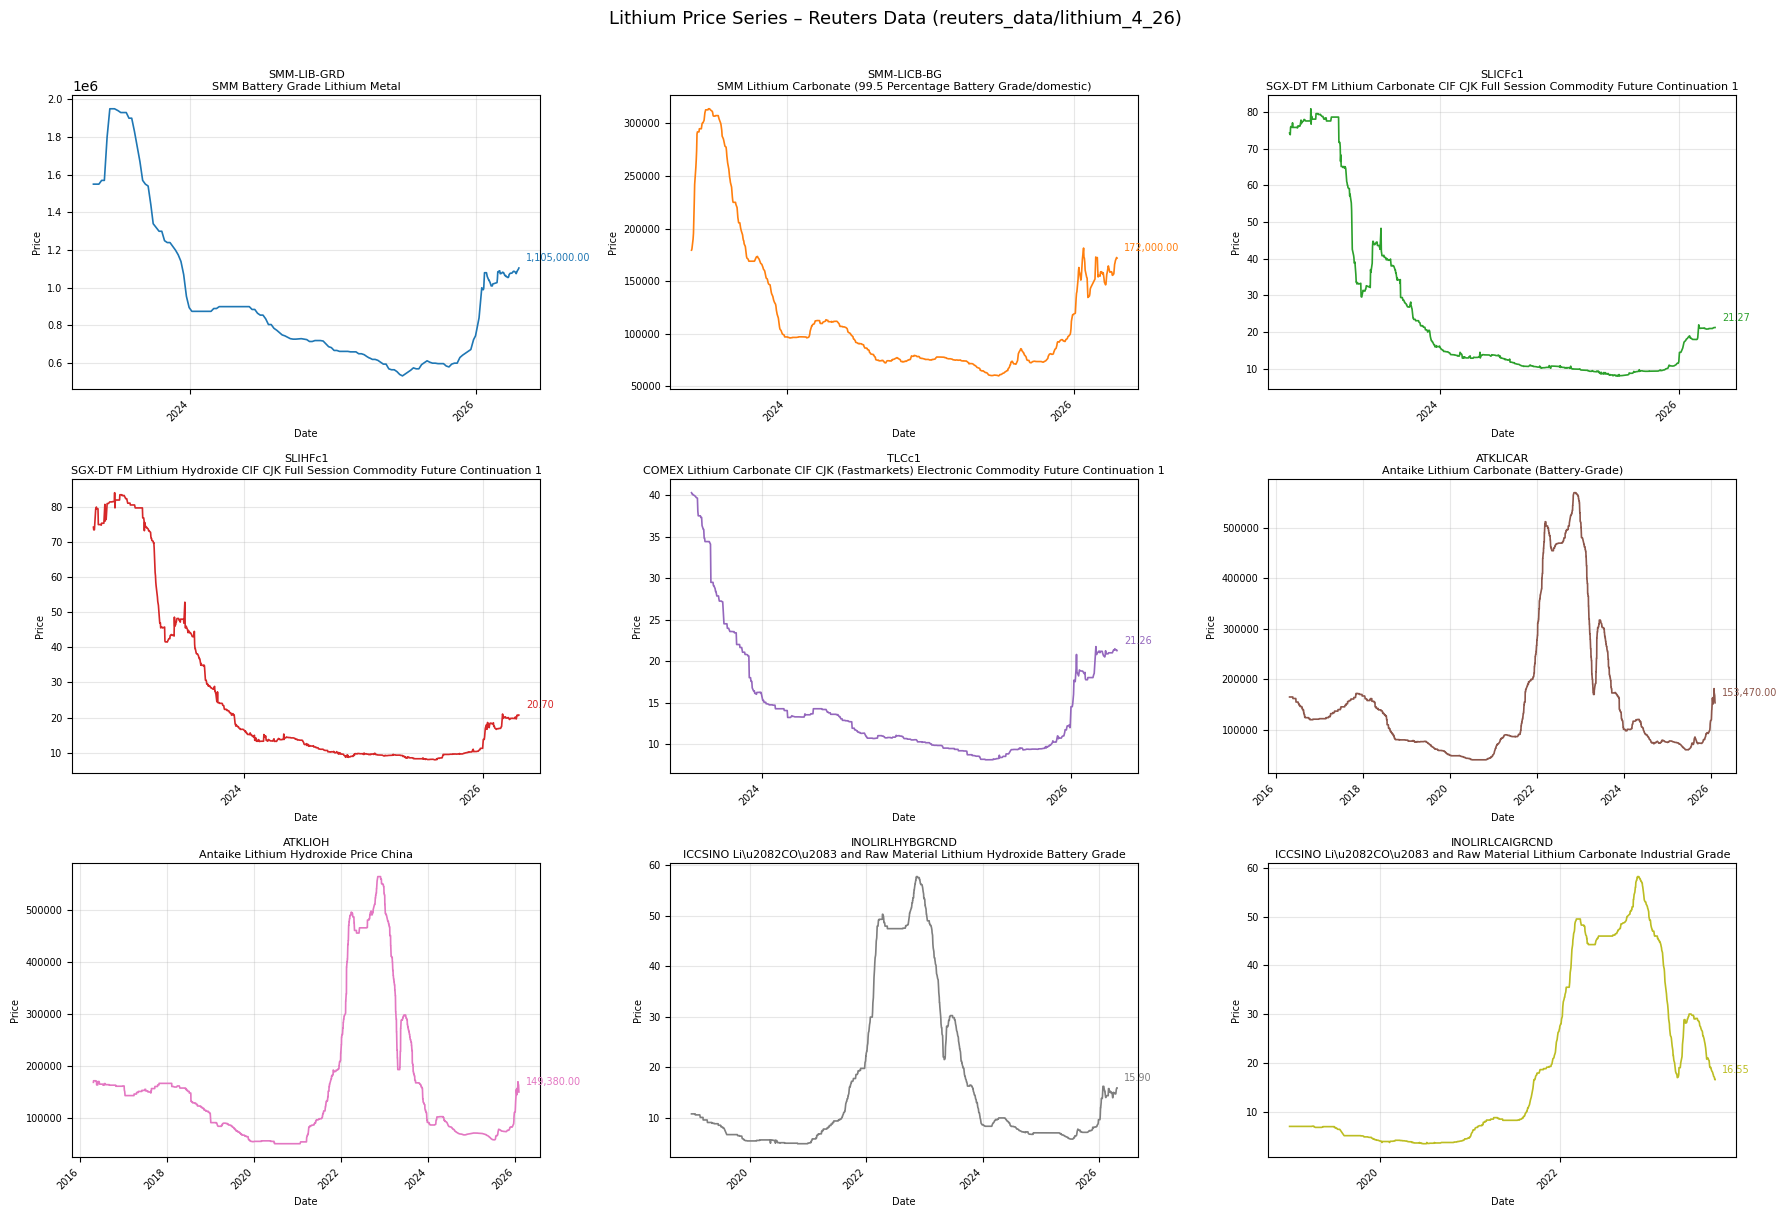

Plot saved to lithium_series_overview.png


In [6]:
tickers = list(series_dict.keys())
n = len(tickers)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes_flat = axes.flatten() if n > 1 else [axes]

# Colour cycle
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for idx, ticker in enumerate(tickers):
    ax = axes_flat[idx]
    info = series_dict[ticker]
    df = info["df"]
    color = colors[idx % len(colors)]

    ax.plot(df["date"], df["price"], linewidth=1.2, color=color)
    ax.set_title(f"{ticker}\n{info['title']}", fontsize=8, pad=4)
    ax.set_xlabel("Date", fontsize=7)
    ax.set_ylabel("Price", fontsize=7)
    ax.tick_params(axis="both", labelsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
    ax.grid(True, alpha=0.3)

    # Annotate latest value
    last = df.iloc[-1]
    ax.annotate(
        f"{last['price']:,.2f}",
        xy=(last["date"], last["price"]),
        xytext=(5, 5), textcoords="offset points",
        fontsize=7, color=color,
    )

# Hide unused subplots
for j in range(n, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle("Lithium Price Series – Reuters Data (reuters_data/lithium_4_26)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(
    os.path.join(output_dir, "lithium_series_overview.png"),
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Plot saved to lithium_series_overview.png")